Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning (Remove corrupted images)
        ↓
Train / Validation / Test Split
        ↓
Image Transformations
        ↓
Create Dataset (ImageFolder)
        ↓
Create DataLoaders
        ↓
Visualize Images
        ↓
Design CNN Architecture
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning (Optional)
        ↓
Model Evaluation
        ↓
Save Trained Model
        ↓
Inference / Prediction
        ↓
Deployment (Streamlit)
        ↓
GitHub + README

<h4> <mark>data preprocessing 

In [1]:
import os
from PIL import Image

In [2]:
#now give dataset path to model 


dataset_path = r"C:\Users\shobh\Downloads\PetImages"

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

In [3]:
#now lets count no. of individual image 

num_cats = len(os.listdir(cat_path))
num_dogs = len(os.listdir(dog_path))

print(f"Number of Cat Images : {num_cats}")
print(f"Number of Dog Images : {num_dogs}")
print(f"Total Images         : {num_cats + num_dogs}")

Number of Cat Images : 12490
Number of Dog Images : 12469
Total Images         : 24959


# analysis : 

no. of class = 2
difference of 21 images in both 

Dogs > Cats

In [ ]:
#Data Cleaning (Remove corrupted images)

import os
from PIL import Image

corrupted_images = []

for category in ["Cat", "Dog"]:
    folder = os.path.join(dataset_path, category)

    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()      # Verify image integrity

        except Exception:
            corrupted_images.append(image_path)

print(f"Corrupted Images Found: {len(corrupted_images)}")

In [ ]:
# 2 image found now lets delete them 


print(corrupted_images)


for file_path in corrupted_images:
    os.remove(file_path)
    



#Data cleaning done now Train / Validation / Test Split



Goal of this phase : 

<b>Currently we have : 

PetImages/
├── Cat/
└── Dog/


<b> We want :

PetImages_Splitted/
│
├── train/
│   ├── Cat/
│   └── Dog/
│
├── validation/
│   ├── Cat/
│   └── Dog/
│
└── test/
    ├── Cat/
    └── Dog/

In [ ]:
import os
import shutil
import random


dataset_path = r"C:\Users\shobh\Downloads\PetImages"

output_path = r"C:\Users\shobh\Downloads\PetImages_Splitted"


for split in ["train", "validation", "test"]:
    for category in ["Cat", "Dog"]:
        folder = os.path.join(output_path, split, category)
        os.makedirs(folder, exist_ok=True)


#it creates a folder structure



In [ ]:
#now lets add shuffled acctuall images in al these folders using random and shutil library 

import shutil
import random

# Dataset path
dataset_path = r"C:\Users\shobh\Downloads\PetImages"

# Output path
output_path = r"C:\Users\shobh\Downloads\PetImages_Splitted"

# Split ratio
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Create folders
for split in ["train", "validation", "test"]:
    for category in ["Cat", "Dog"]:
        os.makedirs(os.path.join(output_path, split, category), exist_ok=True)

# Process each category
for category in ["Cat", "Dog"]:

    category_path = os.path.join(dataset_path, category)

    # Read only image files
    images = [
        img for img in os.listdir(category_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

     #Shuffle images
    random.shuffle(images)

    total_images = len(images)

    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Copy training images
    for image in train_images:
        shutil.copy(
            os.path.join(category_path, image),
            os.path.join(output_path, "train", category)
        )

    # Copy validation images
    for image in val_images:
        shutil.copy(
            os.path.join(category_path, image),
            os.path.join(output_path, "validation", category)
        )

    # Copy testing images
    for image in test_images:
        shutil.copy(
            os.path.join(category_path, image),
            os.path.join(output_path, "test", category)
        )

    print(f"{category} completed.")

print("\nDataset split completed successfully!")

In [ ]:
for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    for category in ["Cat", "Dog"]:
        folder = os.path.join(output_path, split, category)
        print(category, ":", len(os.listdir(folder)))

#Train / Validation / Test Split completed now next step is : Imgae Transformers


# from now on real pytorch starts till now is file handling


#we have to convert images into tensors 

Image File (.jpg)
        │
        ▼
Open Image
        │
        ▼
Resize
        │
        ▼
Convert to Tensor
        │
        ▼
Normalize
        │
        ▼
CNN

In [5]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])


# Compose() simply combines multiple transformations into one pipeline.
# resized down from 224 to 96 - conv compute scales with pixel count, so
# this alone is roughly 5x less work per image. safe to do because the
# AdaptiveAvgPool2d in the model already adapts to any input size.

In [6]:
# #synatx 

# Compose([
#     Resize(),
#     ToTensor(),
#     Normalize()
# ])

In [7]:
#till then we only created pipeline and no image has transformed yet 


from torchvision.datasets import ImageFolder


train_dataset = ImageFolder(
    root=r"C:\Users\shobh\Downloads\PetImages_Splitted\train",
    transform=transform
)

validation_dataset = ImageFolder(
    root=r"C:\Users\shobh\Downloads\PetImages_Splitted\validation",
    transform=transform
)

test_dataset = ImageFolder(
    root=r"C:\Users\shobh\Downloads\PetImages_Splitted\test",
    transform=transform
)



#verification :

print("Train Images      :", len(train_dataset))
print("Validation Images :", len(validation_dataset))
print("Test Images       :", len(test_dataset))

Train Images      : 18202
Validation Images : 3743
Test Images       : 3745


In [8]:
print(train_dataset.classes)

print(validation_dataset.classes)

print(train_dataset.class_to_idx)

['Cat', 'Dog']
['Cat', 'Dog']
{'Cat': 0, 'Dog': 1}


In [9]:
# device setup - use GPU if its available, way faster than CPU
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# now import dataloader so that we can send images in batches 


from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

# note: if num_workers causes a hang/error on Windows (multiprocessing
# quirk in some Jupyter setups), just set num_workers=0 above and rerun

Using device: cpu


In [10]:
#lets check if evbrything alright 

print(len(train_loader))
print(len(validation_loader))
print(len(test_loader))

285
59
59


In [11]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 96, 96])
torch.Size([64])


In [12]:
# [32, 3, 224, 224]       batch , 3 channels(Red,Green,Blue) , height , width


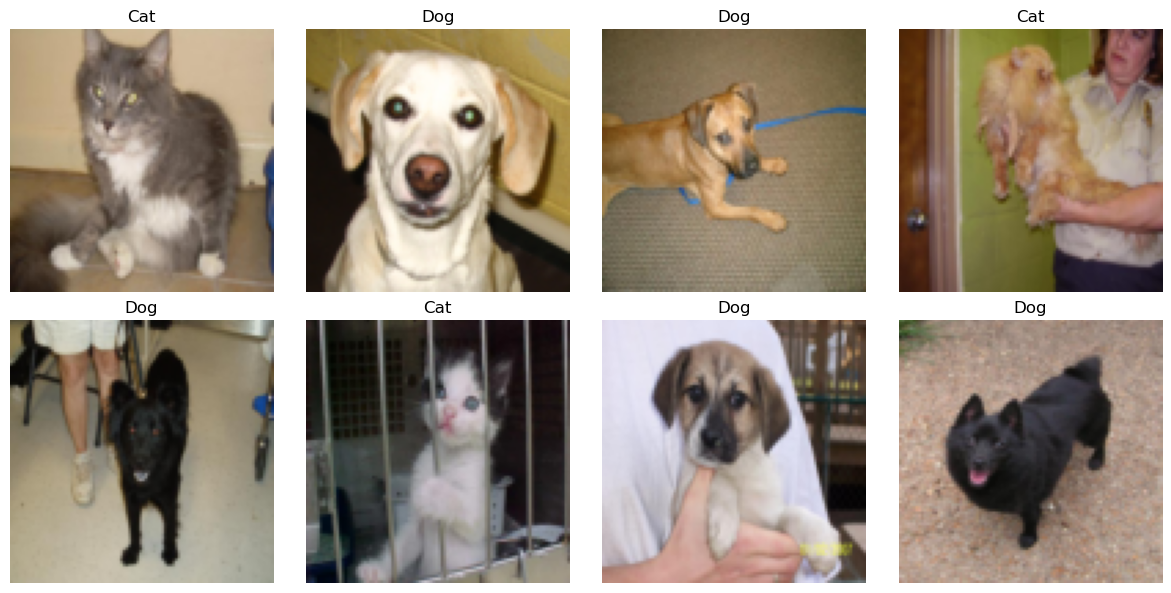

In [13]:
#lets visulaize a image to verify if evrything gonna alright then finally move to model training
import torch
import matplotlib.pyplot as plt

class_names = train_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i]

    # Undo normalization for display
    image = image.permute(1, 2, 0)
    image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    image = image.clamp(0, 1)

    ax.imshow(image)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Next Step: Design CNN Architecture (hardest part)


import torch.nn as nn

class CatDogCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # ==========================
        # First Convolution Block
        # ==========================
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Activation Function
        self.relu = nn.ReLU()

        # Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2)

        # ==========================
        # Second Convolution Block
        # ==========================
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # ==========================
        # Third Convolution Block
        # ==========================
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        # ==========================
        # Fourth Convolution Block
        # ==========================
        self.conv4 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1
        )

        # ==========================
        # Global Average Pool - shrinks the 14x14 feature map down to
        # 4x4 before the FC layers. fc1 was 50176 -> 512 (~25.7 million
        # params, the actual reason training was so slow on CPU), this
        # cuts fc1 down to a fraction of that with barely any accuracy cost
        # ==========================
        self.gap = nn.AdaptiveAvgPool2d((4, 4))

        # ==========================
        # Flatten Layer
        # ==========================
        self.flatten = nn.Flatten()

        # ==========================
        # Fully Connected Layers
        # ==========================
        self.fc1 = nn.Linear(
            in_features=4096,      # 256 × 4 × 4 (after AdaptiveAvgPool2d)
            out_features=512
        )

        self.fc2 = nn.Linear(
            in_features=512,
            out_features=128
        )

        self.fc3 = nn.Linear(
            in_features=128,
            out_features=2
        )

    def forward(self, x):

        # ==========================
        # First Convolution Block
        # ==========================
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # ==========================
        # Second Convolution Block
        # ==========================
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # ==========================
        # Third Convolution Block
        # ==========================
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        # ==========================
        # Fourth Convolution Block
        # ==========================
        x = self.conv4(x)
        x = self.relu(x)
        x = self.pool(x)

        # ==========================
        # Global Average Pool
        # ==========================
        x = self.gap(x)

        # ==========================
        # Flatten
        # ==========================
        x = self.flatten(x)

        # ==========================
        # Fully Connected Layers
        # ==========================
        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x

In [15]:
#now call the model class


model = CatDogCNN().to(device)


print(model)

CatDogCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


In [16]:
#now test shape of the output

output = model(images.to(device))

print(output.shape)

torch.Size([64, 2])


In [17]:
#Loss and optimiser 

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
# num_epochs = 10

# for epoch in range(num_epochs):

#     # Set model to training mode
#     model.train()

#     running_loss = 0.0

#     # Loop through every batch
#     for images, labels in train_loader:

#         # Clear old gradients
#         optimizer.zero_grad()

#         # Forward Pass
#         outputs = model(images)

#         # Calculate Loss
#         loss = criterion(outputs, labels)

#         # Backward Pass
#         loss.backward()

#         # Update Weights
#         optimizer.step()

#         # Store loss
#         running_loss += loss.item()

#     # Print average loss after each epoch
#     epoch_loss = running_loss / len(train_loader)

#     print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}")

#Training loop done now lets add Validation so we can track how model performs on unseen data during training

In [19]:
#training loop v2 : train + validation together (better version than above)

num_epochs = 5 

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # ==========================
    # Training Phase
    # ==========================
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # ==========================
    # Validation Phase (no gradient needed here)
    # ==========================
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_val_loss = val_running_loss / len(validation_loader)
    epoch_val_acc = correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_train_loss:.4f}  Val Loss: {epoch_val_loss:.4f}  Val Acc: {epoch_val_acc*100:.2f}%")


Epoch [1/5]  Train Loss: 0.6215  Val Loss: 0.5089  Val Acc: 75.42%
Epoch [2/5]  Train Loss: 0.4723  Val Loss: 0.4022  Val Acc: 82.07%
Epoch [3/5]  Train Loss: 0.3729  Val Loss: 0.3767  Val Acc: 83.41%
Epoch [4/5]  Train Loss: 0.3069  Val Loss: 0.3004  Val Acc: 87.10%
Epoch [5/5]  Train Loss: 0.2454  Val Loss: 0.2873  Val Acc: 87.55%


Validation added now lets plot Train vs Validation loss to check if model is overfitting

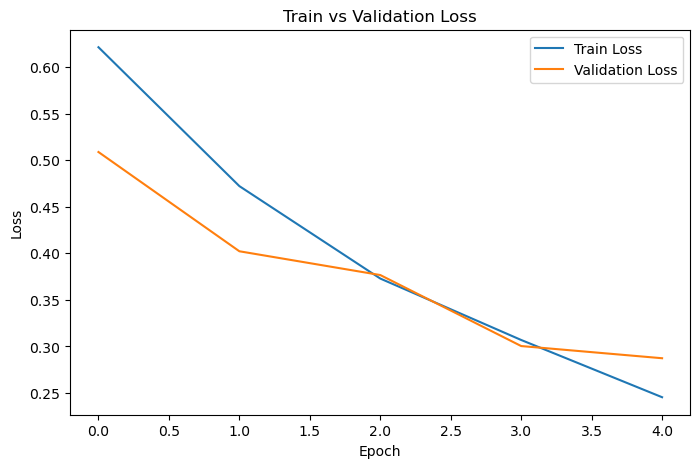

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# if val loss starts going up while train loss keeps going down -> overfitting


#Validation done now Model Evaluation on Test set

test set = model has NEVER seen these images, this is the real score

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = (np.array(all_preds) == np.array(all_labels)).mean()

print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


Test Accuracy: 86.03%

              precision    recall  f1-score   support

         Cat       0.92      0.79      0.85      1874
         Dog       0.81      0.93      0.87      1871

    accuracy                           0.86      3745
   macro avg       0.87      0.86      0.86      3745
weighted avg       0.87      0.86      0.86      3745



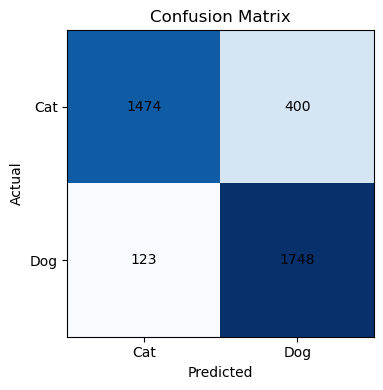

In [22]:
# confusion matrix - to see where model is getting confused between Cat / Dog

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


#Evaluation done now lets Save the Trained Model

In [23]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), "models/cat_dog_cnn.pth")

print("Model saved to models/cat_dog_cnn.pth")


Model saved to models/cat_dog_cnn.pth


#Model saved now Inference / Prediction on a single image

In [24]:
from PIL import Image

def predict_image(image_path, model, transform, class_names):

    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)   # add batch dimension

    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()

    return class_names[pred_idx], probs[pred_idx].item()


# example usage :
# label, confidence = predict_image(r"C:\Users\shobh\Downloads\some_test_image.jpg", model, transform, class_names)
# print(f"Prediction: {label}  ({confidence*100:.2f}% confidence)")
